# Training Data Cleaning and Split

In [1]:
import os
import sys
import logging
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from typing import Literal
from instanovo.transformer.dataset import remove_modifications as clean_peptide

# Fix this later, imports should work without this
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))


from common.utils import collect_files, get_or_create_folder
from common.logger import get_logger_config
from common.constants import (
    BASE_RAW_DATA_DIR,
    BASE_LOGS_DIR,
    BASE_PLOTS_DIR,
    BASE_REPORTS_CSV_DIR,
)

[04/12/25 22:32:23] INFO     Enabling RDKit 2024.09.6 jupyter extensions                             ]8;id=933619;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/rdkit/__init__.py\__init__.py]8;;\:]8;id=13609;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/rdkit/__init__.py#22\22]8;;\

In [7]:
logger_config = get_logger_config(subdir=None)
logging.config.dictConfig(logger_config)
logger = logging.getLogger(__name__)

In [ ]:
logging.warning(
    f"Changing matplotlib font from {plt.rcParams['font.family']} to ['monospace']"
)
plt.rcParams["font.family"] = ["monospace"]

## Remove entries with `precursor_charge` less than 2

## Check how do the peptides in the dataset here overlap the peptides from Kevin

In [8]:
peptides_file_paths = collect_files(BASE_REPORTS_CSV_DIR, ext="csv")

In [9]:
# TODO: Improve the `collect_files` function
peptides_file_paths = [
    path for path in peptides_file_paths if "unique_peptides" in path
]

assert peptides_file_paths, peptides_file_paths
# Grab all csv of interest but ATTENTION;
# loading all many csv files will increase the computation time
df = pd.concat([pd.read_csv(file) for file in peptides_file_paths], ignore_index=True)
df.head(20)

,Unique Peptides
0,HNGTGGR
1,SQNCHNSSSR
2,AAGMNHTK
3,ANASHDQPQK
4,HNDSGASECR
5,GGGGGGGGGGGGGSGSSSGSSTSR
6,RQQQQQQQQQQQQK
7,QQQQQQQQQQQQK
8,KNDSGAYR
9,KCLNHTTQK


In [10]:
df["Unique Peptides"].describe()

count                163595
unique                44976
top       AVCMLSNTTAIAEAWAR
freq                     10
Name: Unique Peptides, dtype: object

In [11]:
unique_peptides_df = df["Unique Peptides"].unique()
pd.DataFrame({"Unique Peptides": unique_peptides_df}).to_csv(
    BASE_REPORTS_CSV_DIR
    / f"overall_projects_unique_peptides_counting_{df['Unique Peptides'].nunique()}.csv",
    index=False,
)

### Overlap with peptides from identity files from Kevin

In [12]:
def compute_and_save_overlap(
    identify_file_path,
    other_peptides,
    split: Literal["train", "test", "valid"] | None = None,
    blacklist_file_path=None,
):  # noqa
    """
    Computes and saves the overlap between peptides in a given identity file and a list of reference peptides.

    Args:
        identify_file_path (str or Path): CSV file path containing identified peptides with an optional 'split' column.
        other_peptides (set or list): Reference peptides to compare against (e.g., from the glyco project).
        split (Literal["train", "test", "valid"], optional): If set, filters peptides in the identity file by this split.
        blacklist_file_path (str or Path, optional): CSV file path containing peptides to exclude from the identity file.

    Saves:
        A CSV file listing the overlapping peptides, with filename reflecting the applied filters (split, blacklist).
    """
    identify_file_path = BASE_REPORTS_CSV_DIR / identify_file_path
    identity_df = pd.read_csv(identify_file_path)
    logger.info(f"Loaded {len(identity_df)} peptides from {identify_file_path}")

    if blacklist_file_path is not None:
        blacklist_df = pd.read_csv(blacklist_file_path)
        blacklist_peptides_set = set(blacklist_df["sequence"])
        identity_df = identity_df[~identity_df["sequence"].isin(blacklist_peptides_set)]
        logger.info(
            f"Filtered out {len(blacklist_peptides_set)} blacklisted peptides and leaving {len(identity_df)} peptides"
        )
    if split is not None:
        identity_df = identity_df[identity_df["split"] == split]
        logger.info(
            f"Got {len(identity_df)} peptides from {identify_file_path} after filtering by {split}"
        )
    # Extract unique peptides from the 'sequence' column
    identity_unique_peptides = set(identity_df["sequence"].unique())
    if isinstance(other_peptides, str):
        other_path = BASE_REPORTS_CSV_DIR / other_peptides
        project_name = other_path.stem
        other_peptides = pd.read_csv(other_path)["sequence"].unique()
        logger.info(
            f"Loaded {len(other_peptides)} glyco projects peptides from {other_path}"
        )
    else:
        project_name = "glyco_projects"
    # Compute overlap now using the cleaned version of the peptides
    overlap_peptides = identity_unique_peptides & {
        clean_peptide(p) for p in other_peptides
    }
    logger.info(
        f"Found {len(overlap_peptides)} {split or 'train/valid/test'} peptides overlap"
    )

    # Save results
    column_name = f"Overlapped {split} peptides" if split else "Overlapped peptides"
    overlap_df = pd.DataFrame({column_name: list(overlap_peptides)})
    output_file_prefix = ""
    if split:
        output_file_prefix += f"{split}_"
    if blacklist_file_path:
        output_file_prefix += "blacklist_"
    output_file = BASE_REPORTS_CSV_DIR / (
        f"{output_file_prefix}overlap_{identify_file_path.stem}_{len(identity_unique_peptides)}_with_{project_name}_{len(other_peptides)}_found_{len(overlap_peptides)}.csv"
    )
    overlap_df.to_csv(output_file, index=False)

    logger.info(f"Saved: {output_file}")

In [13]:
# Compute and save overlaps without any specific filtering
if False:
    logger.info("Compute and save overlaps without any specific filtering")
    identity_files_from_kevin = [
        "identity_splits_proteome_tools_from_kevin.csv",
        "identity_splits_massivekb_from_kevin.csv",
        "identity_splits_blacklist_from_kevin.csv",
        "identity_splits_phospho_from_kevin.csv",
    ]

    for file_path in identity_files_from_kevin:
        compute_and_save_overlap(file_path, unique_peptides_df)

In [14]:
# Compute and save overlaps for train/valid/test but ignoring blacklisted peptides
if False:
    logger.info(
        "Compute and save overlaps for train/valid/test but ignoring blacklisted peptides"
    )
    identity_files_from_kevin = [
        "identity_splits_proteome_tools_from_kevin.csv",
        "identity_splits_massivekb_from_kevin.csv",
        "identity_splits_phospho_from_kevin.csv",
        # "identity_splits_blacklist_from_kevin.csv",
    ]

    for file_path in identity_files_from_kevin:
        for split in ("train", "valid", "test"):
            compute_and_save_overlap(file_path, unique_peptides_df, split=split)

In [15]:
# Compute and save overlaps for train/valid/test and accounting for blacklisted peptides
if False:
    logger.info(
        "Compute and save overlaps for train/valid/test and accounting for blacklisted peptides"
    )
    identity_files_from_kevin = [
        "identity_splits_proteome_tools_from_kevin.csv",
        "identity_splits_massivekb_from_kevin.csv",
        "identity_splits_phospho_from_kevin.csv",
        # Does not make sens to iterate over blacklisted peptides here
        # "identity_splits_blacklist_from_kevin.csv",
    ]

    for file_path in identity_files_from_kevin:
        for split in ("train", "valid", "test"):
            compute_and_save_overlap(
                file_path,
                unique_peptides_df,
                split=split,
                blacklist_file_path=BASE_REPORTS_CSV_DIR
                / "identity_splits_blacklist_from_kevin.csv",
            )

## Split without Kevin constaint

In [13]:
unique_peptides_df

array(['HNGTGGR', 'SQNCHNSSSR', 'AAGMNHTK', ...,
       'IEIIQPLLDMAAGTSNAAPVAENVTNNEGSPPPPVK', 'APPTYDTVMAMEYLDMVLNETLR',
       'EAKAQMEDEDEEEEEEEDEEDNMSTVMR'], dtype=object)

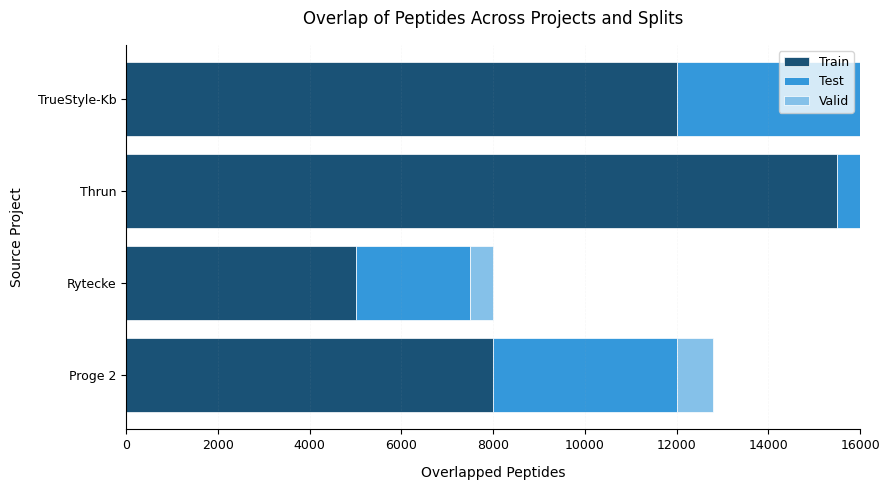

In [75]:
# TODO: Reuse the old save_figure function
# TODO: Group graphing functions together


def save_figure(name, tight=True, dpi=300, ext="pdf", bbox_inches="tight"):
    plt.savefig(f"{name}.{ext}", dpi=dpi, format=ext, bbox_inches=bbox_inches)


def plot_project_overlap(
    df,
    value_col="Overlapped Peptides",
    project_col="Source Project",
    split_col="Split Type",
    save=True,
):
    # Clean and prepare data
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[value_col])

    # Pivot data for stacked bars
    grouped = (
        df.groupby([project_col, split_col])[value_col].sum().unstack(fill_value=0)
    )

    # Set style to match scientific paper
    plt.style.use("default")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.size": 10,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.grid": True,
            "grid.alpha": 0.2,
            "grid.linewidth": 0.5,
        }
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Blue color palette (dark to light)
    colors = {
        "train": "#1a5276",  # dark blue
        "test": "#3498db",  # medium blue
        "valid": "#85c1e9",  # light blue
    }

    # Get ordered splits (train, test, valid)
    ordered_splits = (
        ["train", "test", "valid"]
        if "train" in grouped.columns
        else grouped.columns.tolist()
    )

    # Plot stacked horizontal bars
    left = np.zeros(len(grouped))
    for split in ordered_splits:
        if split in grouped.columns:
            ax.barh(
                grouped.index,
                grouped[split],
                left=left,
                color=colors.get(split.lower(), "#3498db"),
                edgecolor="white",
                linewidth=0.5,
                label=split.capitalize(),
            )
            left += grouped[split]

    # Customize plot
    ax.set_xlabel(value_col, labelpad=10)
    ax.set_ylabel(project_col, labelpad=10)
    ax.set_title("Overlap of Peptides Across Projects and Splits", pad=15)
    ax.set_xlim(0, 16000)

    # Add grid lines
    ax.xaxis.grid(True, linestyle="--", alpha=0.1)
    ax.yaxis.grid(False)

    # Add legend
    ax.legend(loc="upper right", frameon=True)

    # Remove top/right spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()

    if save:
        save_figure("project_overlap_stacked_barplot2")

    plt.show()


# Example data matching wireframe
data = {
    "Source Project": [
        "Thrun",
        "Thrun",
        "Thrun",
        "TrueStyle-Kb",
        "TrueStyle-Kb",
        "TrueStyle-Kb",
        "Proge 2",
        "Proge 2",
        "Proge 2",
        "Rytecke",
        "Rytecke",
        "Rytecke",
    ],
    "Split Type": ["train", "test", "valid"] * 4,
    "Overlapped Peptides": [
        15500,
        7500,
        1500,
        12000,
        6000,
        1200,
        8000,
        4000,
        800,
        5000,
        2500,
        500,
    ],
}
df = pd.DataFrame(data)

plot_project_overlap(df)

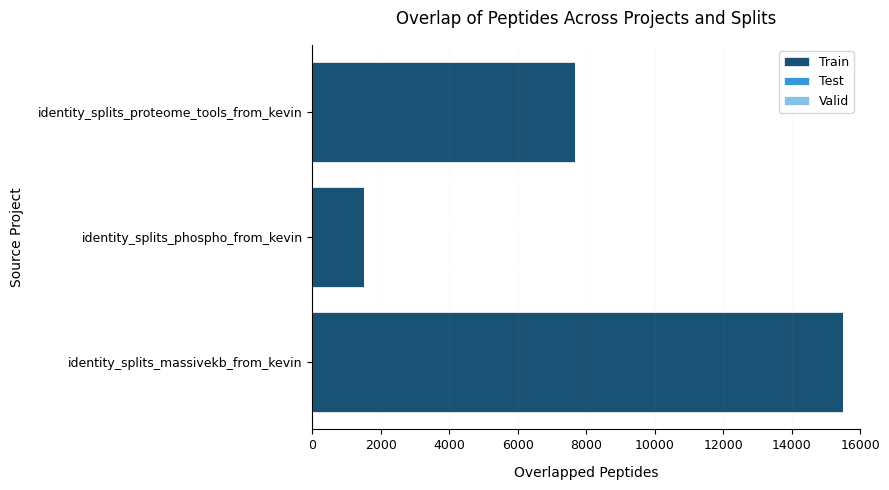

In [76]:
df = pd.read_csv("split_based_structured_overlap_summary_table_with_blacklist.csv")
plot_project_overlap(df)

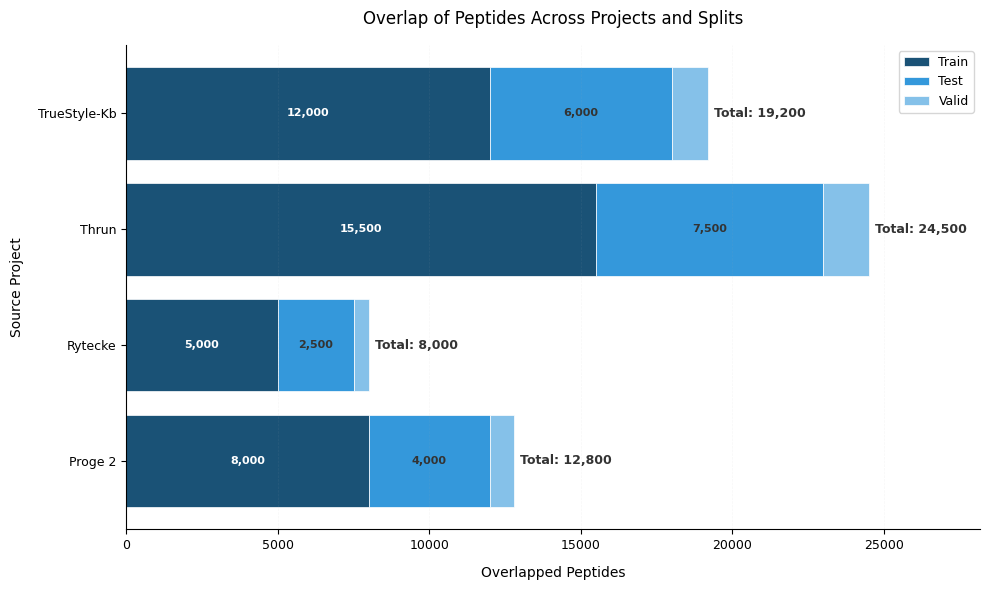

In [81]:
def plot_project_overlap(
    df,
    value_col="Overlapped Peptides",
    project_col="Source Project",
    split_col="Split Type",
    save=True,
):
    # Clean and prepare data
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df.dropna(subset=[value_col])

    # Pivot data for stacked bars
    grouped = (
        df.groupby([project_col, split_col])[value_col].sum().unstack(fill_value=0)
    )

    # Calculate totals for each project
    totals = grouped.sum(axis=1)

    # Set style to match scientific paper
    plt.style.use("default")
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.size": 10,
            "axes.titlesize": 12,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 9,
            "axes.grid": True,
            "grid.alpha": 0.2,
            "grid.linewidth": 0.5,
        }
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Blue color palette (dark to light)
    colors = {
        "train": "#1a5276",  # dark blue
        "test": "#3498db",  # medium blue
        "valid": "#85c1e9",  # light blue
    }

    # Get ordered splits (train, test, valid)
    ordered_splits = (
        ["train", "test", "valid"]
        if "train" in grouped.columns
        else grouped.columns.tolist()
    )

    # Plot stacked horizontal bars
    left = np.zeros(len(grouped))
    for i, split in enumerate(ordered_splits):
        if split in grouped.columns:
            bars = ax.barh(
                grouped.index,
                grouped[split],
                left=left,
                color=colors.get(split.lower(), "#3498db"),
                edgecolor="white",
                linewidth=0.5,
                label=split.capitalize(),
            )

            # Add value labels for train and test only
            if split in ["train", "test"]:
                for bar, value in zip(bars.patches, grouped[split]):
                    if value > 0:
                        width = bar.get_width()
                        x = bar.get_x() + width / 2
                        y = bar.get_y() + bar.get_height() / 2
                        ax.text(
                            x,
                            y,
                            f"{value:,.0f}",
                            ha="center",
                            va="center",
                            color="white" if split == "train" else "#333333",
                            fontsize=8,
                            fontweight="bold",
                        )

            left += grouped[split]

    # Add total labels at the end of each bar
    for i, (project, total) in enumerate(zip(grouped.index, totals)):
        ax.text(
            total + 200,
            i,
            f"Total: {total:,.0f}",
            va="center",
            ha="left",
            color="#333333",
            fontsize=9,
            fontweight="bold",
        )

    # Customize plot
    ax.set_xlabel(value_col, labelpad=10)
    ax.set_ylabel(project_col, labelpad=10)
    ax.set_title("Overlap of Peptides Across Projects and Splits", pad=15)
    ax.set_xlim(0, max(totals) * 1.15)  # Dynamic xlim with 15% padding

    # Add grid lines
    ax.xaxis.grid(True, linestyle="--", alpha=0.1)
    ax.yaxis.grid(False)

    # Add legend
    ax.legend(loc="upper right", frameon=True)

    # Remove top/right spines
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()

    if save:
        save_figure("project_overlap_with_counts")

    plt.show()


# Example data
data = {
    "Source Project": [
        "Thrun",
        "Thrun",
        "Thrun",
        "TrueStyle-Kb",
        "TrueStyle-Kb",
        "TrueStyle-Kb",
        "Proge 2",
        "Proge 2",
        "Proge 2",
        "Rytecke",
        "Rytecke",
        "Rytecke",
    ],
    "Split Type": ["train", "test", "valid"] * 4,
    "Overlapped Peptides": [
        15500,
        7500,
        1500,
        12000,
        6000,
        1200,
        8000,
        4000,
        800,
        5000,
        2500,
        500,
    ],
}
df = pd.DataFrame(data)

plot_project_overlap(df)

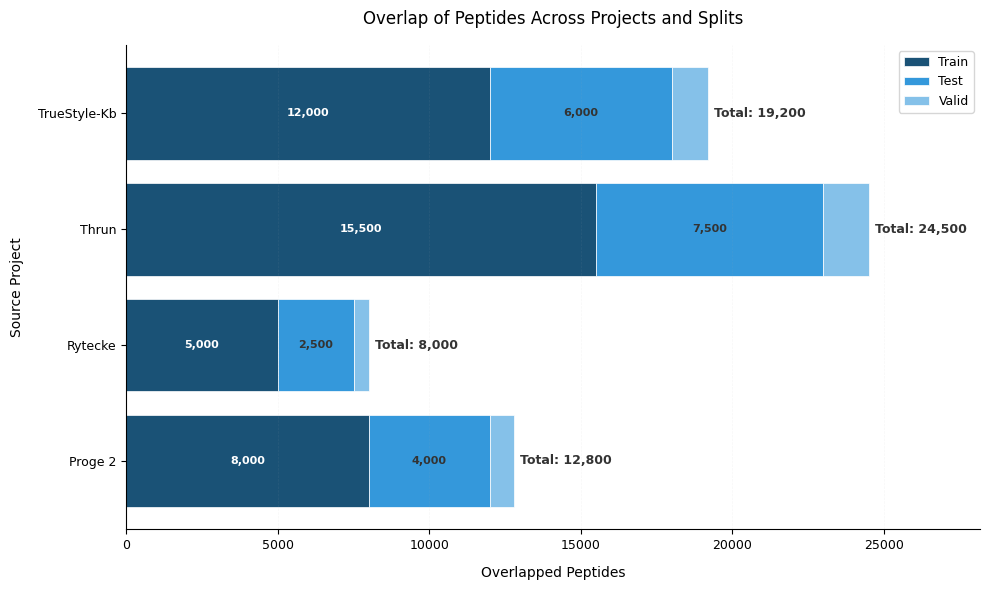

In [82]:
plot_project_overlap(df)

In [ ]:
rr = pd.read_parquet(
    BASE_PROCESSED_DATA_DIR / "PXD035158/dataset-ms-glyco_v1_train-0001-0001.parquet"
)
rr.head()

In [72]:
def plot_split_distribution(
    projects,
    train,
    valid,
    test,
    split_hatches=[".", "O", "-"],
    project_colors=plt.cm.tab20.colors[:8],
    figsize=(10, 6),
    save_path=None,
    dpi=300,
):
    """
    Creates a nested pie chart visualization for dataset splits.

    Parameters:
    - projects: List of project IDs
    - train: List of train split counts for each project
    - valid: List of valid split counts for each project
    - test: List of test split counts for each project
    - split_hatches: Hatch patterns for splits (outer ring)
    - project_colors: Color palette for projects (inner ring)
    - figsize: Figure size
    - save_path: Path to save the figure (None to disable saving)
    - dpi: Output resolution
    """
    # Calculate sizes and percentages
    outer_sizes = [sum(train), sum(valid), sum(test)]
    inner_sizes = train + valid + test
    total = sum(outer_sizes)
    split_percentages = [(size / total) * 100 for size in outer_sizes]

    # Create labels with percentages
    split_labels = [
        # f'Train ({outer_sizes[0]:,}, {split_percentages[0]:.1f}%)',
        f"Train {split_percentages[0]:.1f}%",
        # f'Valid ({outer_sizes[1]:,}, {split_percentages[1]:.1f}%)',
        f"Valid {split_percentages[1]:.1f}%",
        # f'Test ({outer_sizes[2]:,}, {split_percentages[2]:.1f}%)'
        f"Test {split_percentages[2]:.1f}%",
    ]

    # Setup plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("equal")

    # Outer ring (splits)
    outer_pie = ax.pie(
        outer_sizes,
        labels=None,
        colors=["white"] * 3,
        radius=1.3,
        startangle=90,
        wedgeprops={"edgecolor": "black", "linewidth": 0.5},
    )
    for i, wedge in enumerate(outer_pie[0]):
        wedge.set_hatch(split_hatches[i])

    # Inner ring (projects)
    inner_pie = ax.pie(
        inner_sizes,
        colors=project_colors * 3,  # Repeat colors for each split
        radius=1.0,
        startangle=90,
        wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 0.5},
    )

    # Legends
    split_legend = [
        plt.Rectangle((0, 0), 1, 1, fc="lightgray", hatch=h, edgecolor="black")
        for h in split_hatches
    ]
    project_legend = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in project_colors]

    leg1 = ax.legend(
        split_legend,
        split_labels,
        title=f"{total} Splits",
        loc="upper left",
        bbox_to_anchor=(1.01, 1.0),
        frameon=True,
    )

    leg2 = ax.legend(
        project_legend,
        projects,
        title="Projects",
        loc="lower left",
        bbox_to_anchor=(1.01, 0.0),
        frameon=True,
    )

    ax.add_artist(leg1)
    plt.subplots_adjust(right=0.7)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

[04/13/25 01:44:31] WARNING  Ignoring fixed x limits to fulfill fixed data aspect with adjustable     ]8;id=844253;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py\_base.py]8;;\:]8;id=76927;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py#2090\2090]8;;\
                             data limits.                                                                          

                    WARNING  Ignoring fixed x limits to fulfill fixed data aspect with adjustable     ]8;id=652261;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py\_base.py]8;;\:]8;id=520196;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py#2090\2090]8;;\
                             data limits.                                                                          

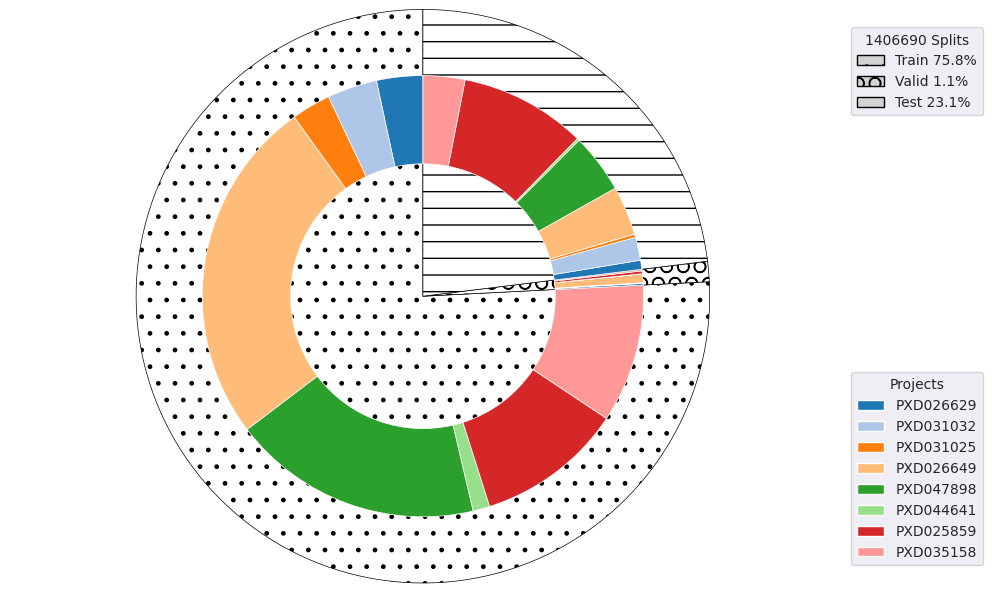

In [71]:
split_dist_version1_df = pd.read_csv(
    BASE_REPORTS_CSV_DIR / "version1_dataset_split_distribution_summary.csv"
)

# Prepare parameters
plot_params1 = {
    "projects": split_dist_version1_df["Project"].tolist(),
    "train": split_dist_version1_df["Train"].tolist(),
    "valid": split_dist_version1_df["Valid"].tolist(),
    "test": split_dist_version1_df["Test"].tolist(),
    "save_path": BASE_PLOTS_DIR / "split_version1_distribution_pie.pdf",
}

# Generate plot
plot_split_distribution(**plot_params1)

[04/13/25 01:53:04] WARNING  Ignoring fixed x limits to fulfill fixed data aspect with adjustable     ]8;id=316182;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py\_base.py]8;;\:]8;id=130300;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py#2090\2090]8;;\
                             data limits.                                                                          

                    WARNING  Ignoring fixed x limits to fulfill fixed data aspect with adjustable     ]8;id=957406;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py\_base.py]8;;\:]8;id=718739;file:///home/hjisaac/.cache/pypoetry/virtualenvs/instanovoglyco-u5tn6RZG-py3.10/lib/python3.10/site-packages/matplotlib/axes/_base.py#2090\2090]8;;\
                             data limits.                                                                          

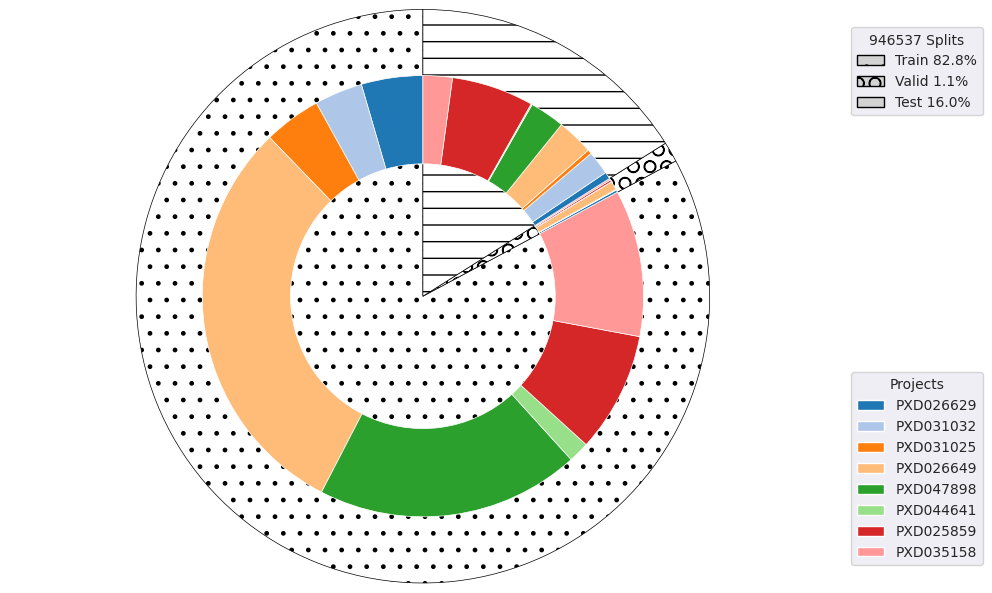

In [73]:
split_dist_version2_df = pd.read_csv(
    BASE_REPORTS_CSV_DIR / "version2_dataset_split_distribution_summary.csv"
)

# Prepare parameters
plot_params2 = {
    "projects": split_dist_version2_df["Project"].tolist(),
    "train": split_dist_version2_df["Train"].tolist(),
    "valid": split_dist_version2_df["Valid"].tolist(),
    "test": split_dist_version2_df["Test"].tolist(),
    "save_path": BASE_PLOTS_DIR / "split_version2_distribution_pie.pdf",
}

# Generate plot
plot_split_distribution(**plot_params2)